# jaxsedfit: NGC 5548 Joint SED + SDSS Spectrum Fit

This notebook uses Bandwagon to collect broadband photometry and discover SDSS spectra for NGC 5548, then fits both data sets with one `jaxsedfit` model. The joint model shares the jaxsedfit host and AGN continuum with the spectroscopic likelihood. Broadband photometry keeps jaxsedfit's native SED-scale AGN features, while the SDSS spectral likelihood adds jaxqsofit's detailed tied-line, Fe II, and Balmer components on top of the shared continuum.


In [1]:
from pathlib import Path
import inspect
import sys

import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.sdss import SDSS
import matplotlib.pyplot as plt
import numpy as np
import numpyro.distributions as dist

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "jaxsedfit").is_dir():
    repo_root = repo_root.parent
bandwagon_root = repo_root.parent / "bandwagon"
jaxqsofit_root = repo_root.parent / "jaxqsofit"
src_roots = [repo_root / "src", bandwagon_root / "src", jaxqsofit_root / "src"]
for src_root in reversed(src_roots):
    src_path = str(src_root)
    if src_root.is_dir():
        sys.path[:] = [path for path in sys.path if path != src_path]
        sys.path.insert(0, src_path)

# Notebook kernels keep imported modules alive between edits. Drop local source
# packages so rerunning this cell always uses the sibling source trees above.
for module_name in list(sys.modules):
    if module_name == "bandwagon" or module_name.startswith("bandwagon."):
        del sys.modules[module_name]
    if module_name == "jaxsedfit" or module_name.startswith("jaxsedfit."):
        del sys.modules[module_name]
    if module_name == "jaxqsofit" or module_name.startswith("jaxqsofit."):
        del sys.modules[module_name]

import bandwagon
from bandwagon import matches_to_photometry, query_archival_spectra, xmatch_catalogs
from jaxsedfit.filters import load_filter_curves
from jaxsedfit import (
    AGNConfig,
    FilterSet,
    FitConfig,
    JAXSEDFit,
    GalaxyConfig,
    InferenceConfig,
    JaxQSOFitConfig,
    LikelihoodConfig,
    Observation,
    PhotometryData,
    SpectroscopyConfig,
    SpectroscopyData,
)

if "enrich_sdss_psf" not in inspect.signature(xmatch_catalogs).parameters:
    raise RuntimeError(
        "This notebook imported an older BandWagon without SDSS PSF enrichment. "
        "Restart the kernel or rerun this import cell. "
        f"Imported bandwagon from: {bandwagon.__file__}"
    )

if "backend" not in inspect.signature(SpectroscopyConfig).parameters:
    raise RuntimeError(
        "This notebook imported an older jaxsedfit.SpectroscopyConfig without "
        "the backend option. Restart the kernel or rerun this import cell. "
        f"Imported jaxsedfit from: {sys.modules['jaxsedfit'].__file__}"
    )

print(f"Using bandwagon from: {bandwagon.__file__}")


/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Could not import regions, which is required for some of the functionalities of this module.
Using bandwagon from: /Users/colinburke/research/bandwagon/src/bandwagon/__init__.py


In [2]:
DSPS_SSP_FN = repo_root.parent / "jaxqsofit" / "tempdata.h5"

coord = SkyCoord(184.0307, -2.2383, unit='deg')

OBJECT_NAME = "SDSSJ121607.37-021418.0"

## Query Bandwagon Photometry


In [3]:
matches = xmatch_catalogs(coord, source_id=[OBJECT_NAME], cache=False)
for name, table in matches.items():
    print(f"{name}: {len(table)} matched rows")

sdss_table = matches.get("sdss_dr16")
if sdss_table is None or len(sdss_table) == 0:
    raise RuntimeError(
        "BandWagon did not return an SDSS DR16 match, so SDSS PSF photometry "
        "cannot appear in the SED plot. Check the XMatch result and match radius."
    )

required_psf_cols = {"upmag", "gpmag", "rpmag", "ipmag", "zpmag", "e_upmag", "e_gpmag", "e_rpmag", "e_ipmag", "e_zpmag"}
missing_psf_cols = sorted(required_psf_cols - set(sdss_table.colnames))
if missing_psf_cols:
    raise RuntimeError(
        "SDSS matched, but BandWagon did not enrich the XMatch result with PSF columns. "
        f"Missing columns: {missing_psf_cols}. "
        f"Imported bandwagon from: {bandwagon.__file__}"
    )

phot = matches_to_photometry(matches, max_mag_err=1.0)
phot = phot[np.isfinite(phot["flux_mjy"]) & np.isfinite(phot["flux_err_mjy"]) & (phot["flux_err_mjy"] > 0)]
if "speclite_name" in phot.colnames:
    phot.remove_column("speclite_name")
if "photometry_method" not in phot.colnames:
    raise RuntimeError("BandWagon must provide photometry_method so SDSS PSF photometry can be identified.")

sdss_filters = {f"{band}_sdss" for band in "ugriz"}
found_sdss = sorted(sdss_filters & {str(name) for name in phot["filter_name"]})
missing_sdss = sorted(sdss_filters - set(found_sdss))
if missing_sdss:
    raise RuntimeError(
        "BandWagon returned an SDSS match, but the long-form photometry table is missing "
        f"these SDSS PSF bands: {missing_sdss}. Available filters: "
        f"{[str(name) for name in phot['filter_name']]}"
    )

sdss_methods = {
    str(row["filter_name"]): str(row["photometry_method"])
    for row in phot
    if str(row["filter_name"]) in sdss_filters
}
if any(method != "psf" for method in sdss_methods.values()):
    raise RuntimeError(f"SDSS photometry must be PSF-only, got methods: {sdss_methods}")

print("BandWagon SDSS PSF photometry:", found_sdss)
phot.sort("match_distance_arcsec")
phot["catalog", "filter_name", "photometry_method", "flux_mjy", "flux_err_mjy", "psf_fwhm_arcsec", "match_distance_arcsec"]



galex_ais: 1 matched rows
sdss_dr16: 2 matched rows
2mass: 1 matched rows
allwise: 1 matched rows
legacy_dr8_north: 0 matched rows
legacy_dr8_south: 1 matched rows
BandWagon SDSS PSF photometry: ['g_sdss', 'i_sdss', 'r_sdss', 'u_sdss', 'z_sdss']


catalog,filter_name,photometry_method,flux_mjy,flux_err_mjy,psf_fwhm_arcsec,match_distance_arcsec
str9,str9,str7,float64,float64,float64,float64
sdss_dr16,g_sdss,psf,0.25490024266214417,0.005142734962788508,1.44,0.320442
sdss_dr16,i_sdss,psf,0.6352932616122613,0.006574009845718945,1.26,0.320442
sdss_dr16,r_sdss,psf,0.44331277736257696,0.004936458186597454,1.32,0.320442
sdss_dr16,u_sdss,psf,0.09367296109230128,0.0022886922454951808,1.53,0.320442
sdss_dr16,z_sdss,psf,0.7366857155730032,0.01197610733280229,1.29,0.320442
allwise,W1,catalog,2.12969162641557,0.05492251904185422,6.08,0.336625
allwise,W2,catalog,1.8272183629081464,0.05217083862191937,6.84,0.336625
allwise,W3,catalog,5.075781820771904,0.33659766871723795,7.36,0.336625
allwise,W4,catalog,14.506482439538885,2.4183344232632495,11.99,0.336625


## Query Bandwagon SDSS Spectra


In [4]:
spectra = query_archival_spectra(
    coord,
    source_id=[OBJECT_NAME],
    providers=("sdss",),
    radius_arcsec=5.0,
)
spectra.sort("redshift")
spectra[
    "provider",
    "release",
    "obs_id",
    "redshift",
    "quality",
    "sdss_plate",
    "sdss_mjd",
    "sdss_fiberid",
]

provider,release,obs_id,redshift,quality,sdss_plate,sdss_mjd,sdss_fiberid
str4,str4,str13,float64,str1,str3,str5,str3
sdss,dr17,332-52367-639,0.1006098,,332,52367,639


In [5]:
sdss_rows = spectra[spectra["provider"] == "sdss"]
if len(sdss_rows) == 0:
    raise RuntimeError("No SDSS spectrum was found for NGC 5548.")

# Prefer rows with clean SDSS zwarning when available.
quality = np.asarray([str(q).strip() for q in sdss_rows["quality"]])
clean = np.flatnonzero((quality == "0") | (quality == ""))
row = sdss_rows[int(clean[0])] if clean.size else sdss_rows[0]

plate = int(row["sdss_plate"])
mjd = int(row["sdss_mjd"])
fiberid = int(row["sdss_fiberid"])
redshift = float(row["redshift"])
print(f"Using SDSS spectrum plate={plate}, mjd={mjd}, fiber={fiberid}, z={redshift:.5f}")

sdss_hdul = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiberid)[0]
sdss_data = sdss_hdul[1].data
wave_obs = 10.0 ** np.asarray(sdss_data["loglam"], dtype=float)
flux_1e17 = np.asarray(sdss_data["flux"], dtype=float)
ivar = np.asarray(sdss_data["ivar"], dtype=float)
err_1e17 = np.where(ivar > 0.0, 1.0 / np.sqrt(ivar), np.nan)

Using SDSS spectrum plate=332, mjd=52367, fiber=639, z=0.10061


/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_10994/3392352384.py:21: RuntimeWarning: divide by zero encountered in divide
  err_1e17 = np.where(ivar > 0.0, 1.0 / np.sqrt(ivar), np.nan)


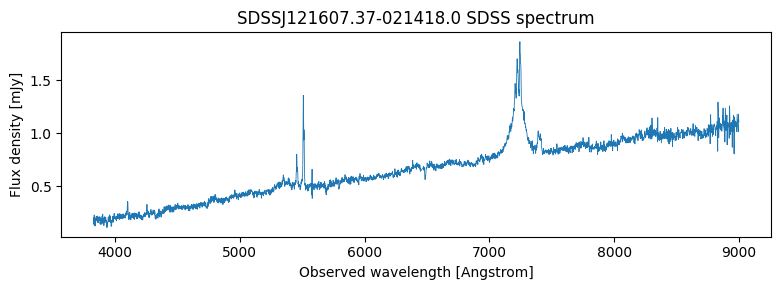

In [6]:
C_ANG_PER_S = 2.99792458e18

def flambda_1e17_to_mjy(wave_angstrom, flux_1e17):
    f_lambda_cgs = np.asarray(flux_1e17, dtype=float) * 1.0e-17
    f_nu_cgs = f_lambda_cgs * np.asarray(wave_angstrom, dtype=float) ** 2 / C_ANG_PER_S
    return f_nu_cgs / 1.0e-26


spec_flux_mjy = flambda_1e17_to_mjy(wave_obs, flux_1e17)
spec_err_mjy = flambda_1e17_to_mjy(wave_obs, err_1e17)
spec_mask = (
    np.isfinite(wave_obs)
    & np.isfinite(spec_flux_mjy)
    & np.isfinite(spec_err_mjy)
    & (spec_err_mjy > 0.0)
    & (wave_obs > 3600.0)
    & (wave_obs < 9000.0)
)

plt.figure(figsize=(8, 3))
plt.plot(wave_obs[spec_mask], spec_flux_mjy[spec_mask], lw=0.6)
plt.xlabel("Observed wavelength [Angstrom]")
plt.ylabel("Flux density [mJy]")
plt.title(f"{OBJECT_NAME} SDSS spectrum")
plt.tight_layout()

In [7]:
spec_wave_native = wave_obs[spec_mask]
spec_flux_native = spec_flux_mjy[spec_mask]
spec_err_native = spec_err_mjy[spec_mask]

print(f"Using {spec_wave_native.size:,} native SDSS spectral pixels")


Using 3,690 native SDSS spectral pixels


## Build A Joint Photometry + Spectrum Config


In [ ]:
filter_names = [str(name) for name in phot["filter_name"]]
required_sdss_filters = {f"{band}_sdss" for band in "ugriz"}
missing_sdss_filters = sorted(required_sdss_filters - set(filter_names))
if missing_sdss_filters:
    raise RuntimeError(
        "The fit config is being built without SDSS PSF photometry. "
        f"Missing filters: {missing_sdss_filters}. Rerun the BandWagon photometry cell above."
    )

cfg = FitConfig(
    observation=Observation(
        object_id="NGC5548_joint",
        redshift=redshift,
        redshift_mode="fixed",
        ra=float(coord.ra.deg),
        dec=float(coord.dec.deg),
        apply_mw_deredden=False,
    ),
    photometry=PhotometryData(
        filter_names=filter_names,
        fluxes=[float(x) for x in phot["flux_mjy"]],
        errors=[float(x) for x in phot["flux_err_mjy"]],
        is_upper_limit=[False] * len(phot),
        psf_fwhm_arcsec=[float(x) if np.isfinite(x) else None for x in phot["psf_fwhm_arcsec"]],
        photometry_method=[str(x) for x in phot["photometry_method"]],
    ),
    filters=FilterSet(curves=load_filter_curves(filter_names)),
    spectroscopy=SpectroscopyData(
        wave_obs=spec_wave_native.tolist(),
        fluxes=spec_flux_native.tolist(),
        errors=spec_err_native.tolist(),
        mask=[True] * len(spec_wave_native),
        instrument="SDSS",
        aperture_diameter_arcsec=3.0,
    ),
    spectroscopy_config=SpectroscopyConfig(
        enabled=True,
        backend="jaxqsofit",
        fit_scale=True,
        scale_prior_sigma_dex=0.4,
        systematics_width=0.08,
        student_t_df=5.0,
        likelihood_weight_mode="resolution_elements",
        resolving_power=2000.0,
        # These jaxqsofit switches affect only the spectroscopic likelihood.
        # Photometric fluxes still use jaxsedfit native SED-scale AGN features.
        jaxqsofit=JaxQSOFitConfig(
            use_spectral_lines=True,
            use_tied_lines=True,
            use_spectral_smart_priors=True,
            use_spectral_feii=True,
            use_spectral_balmer_continuum=True,
            line_flux_scale_mjy=0.1,
        ),
    ),
    galaxy=GalaxyConfig(
        dsps_ssp_fn=str(DSPS_SSP_FN),
        n_wave=512,
        rest_wave_min=100.0,
        rest_wave_max=3.0e6,
        fit_host_kinematics=True,
    ),
    agn=AGNConfig(
        agn_type=1,
        # In joint mode, jaxqsofit owns the spectral Fe II and Balmer continuum.
        fit_balmer_continuum=False,
    ),
    likelihood=LikelihoodConfig(
        use_host_capture_model=True,
        systematics_width=0.08,
    ),
    inference=InferenceConfig(map_steps=600, learning_rate=5.0e-3, seed=3, num_warmup=250, num_samples=250, num_chains=1,),
)
cfg.prior_config.agn.log_broad_line_width_kms = dist.TruncatedNormal(
    loc=np.log(3000.0),
    scale=0.4,
    low=np.log(1000.0),
    high=np.log(15000.0),
)
cfg.prior_config.agn.log_narrow_line_width_kms = dist.TruncatedNormal(
    loc=np.log(500.0),
    scale=0.3,
    low=np.log(100.0),
    high=np.log(1500.0),
)
cfg.validate()
cfg



## Fit

The first run below uses MAP/SVI with staged continuum-first initialization, which is now the default for `InferenceConfig.method="optax"`. Increase `optax_steps` or set `cfg.inference.method = "optax+nuts"` once the model and data choices look sensible.


In [ ]:
cfg.inference.method = "optax+nuts"
cfg.output.plot_fig = False
cfg.output.save_fig = False
cfg.output.save_result = False
fitter = JAXSEDFit(cfg)
result = fitter.fit(progress_bar=True)
result.summary


In [10]:
pred = fitter.predict()
print(f"Joint backend: {cfg.spectroscopy_config.backend}")
print("Spectra in model context:", len(fitter.context.spec_instruments))
print("Spectrum instruments:", fitter.context.spec_instruments)
print("Predictive spectral sites:", sorted(k for k in pred if k.startswith("jqf_") or k.startswith("pred_spectrum")))

Joint backend: jaxqsofit
Spectra in model context: 1
Spectrum instruments: ('SDSS',)
Predictive spectral sites: ['jqf_balmer_model', 'jqf_continuum_model', 'jqf_feii_model', 'jqf_line_amp_per_component', 'jqf_line_model', 'jqf_line_model_broad', 'jqf_line_model_narrow', 'jqf_line_mu_per_component', 'jqf_line_narrow_amp_scale', 'jqf_line_narrow_fwhm_kms', 'jqf_line_sig_per_component', 'jqf_total_model', 'pred_spectrum_fluxes']


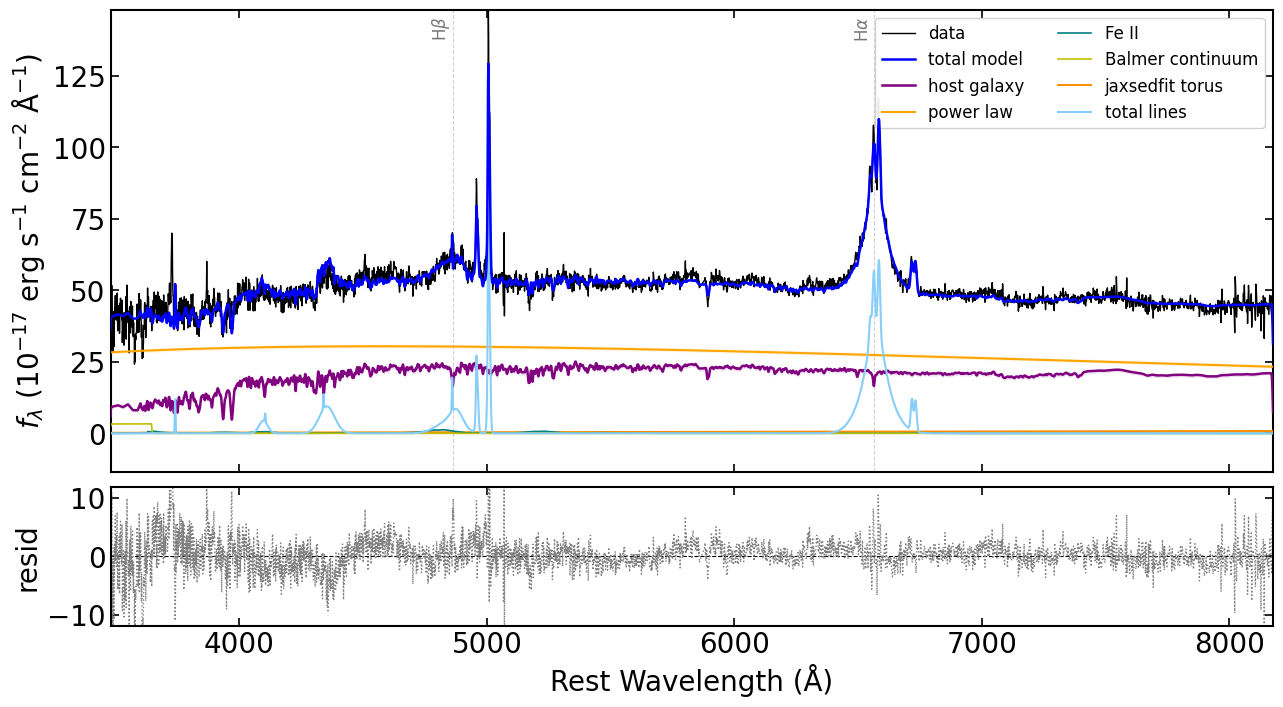

In [11]:
fig = fitter.plot_jaxqsofit_spectrum(
    spectrum_index=0,
    show_plot=True,
    plot_residual=True,
    plot_legend=True,
)

/Users/colinburke/research/jaxsedfit/src/jaxsedfit/plotting.py:525: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


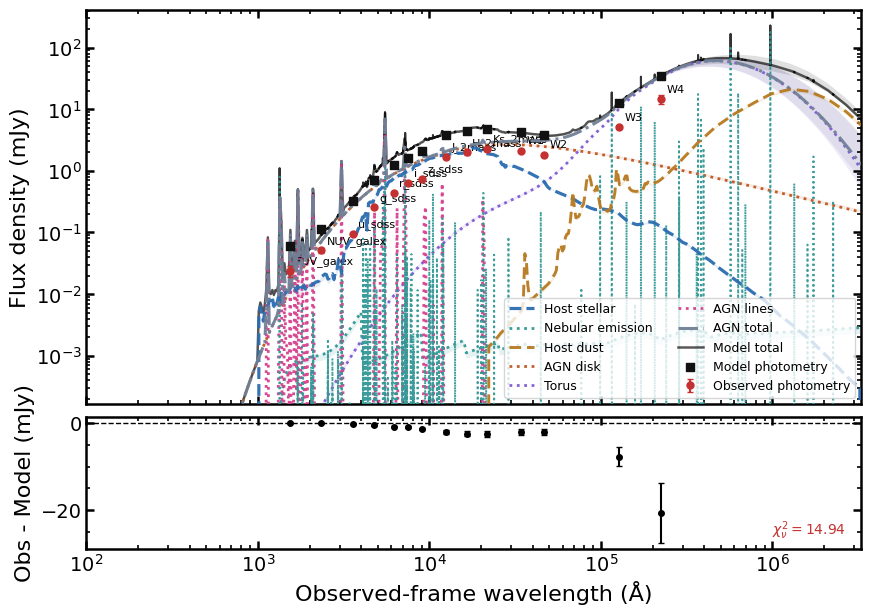

In [12]:
fitter.plot_sed(annotate_band_names=True)
